In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Task 1 - hough line transformation

In [2]:
image_path = "computer-lab.jpg"
img = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img.shape

(411, 738, 3)

In [3]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
edges[:150] = 0

def draw_lines(image, lines, tol=12):
  out = image.copy()
  kept = 0
  for x1, y1, x2, y2 in lines.reshape(-1, 4):
    angle = abs(np.degrees(np.arctan2(y2-y1, x2-x1)))
    if angle < tol or angle > 180-tol or abs(angle-90) < tol:
      cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
      kept += 1
  return out, kept

In [6]:
votes = [40, 60, 80]
panels = [('Edges', edges)]

for v in votes:
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, v, minLineLength=40, maxLineGap=8)
    result, kept = draw_lines(img, lines)
    print(f'votes={v} - lines found:', len(lines), 'horizontal/vertical:', kept)
    panels.append((f'Votes={v}', result))

votes=40 - lines found: 92 horizontal/vertical: 91
votes=60 - lines found: 87 horizontal/vertical: 87
votes=80 - lines found: 66 horizontal/vertical: 66


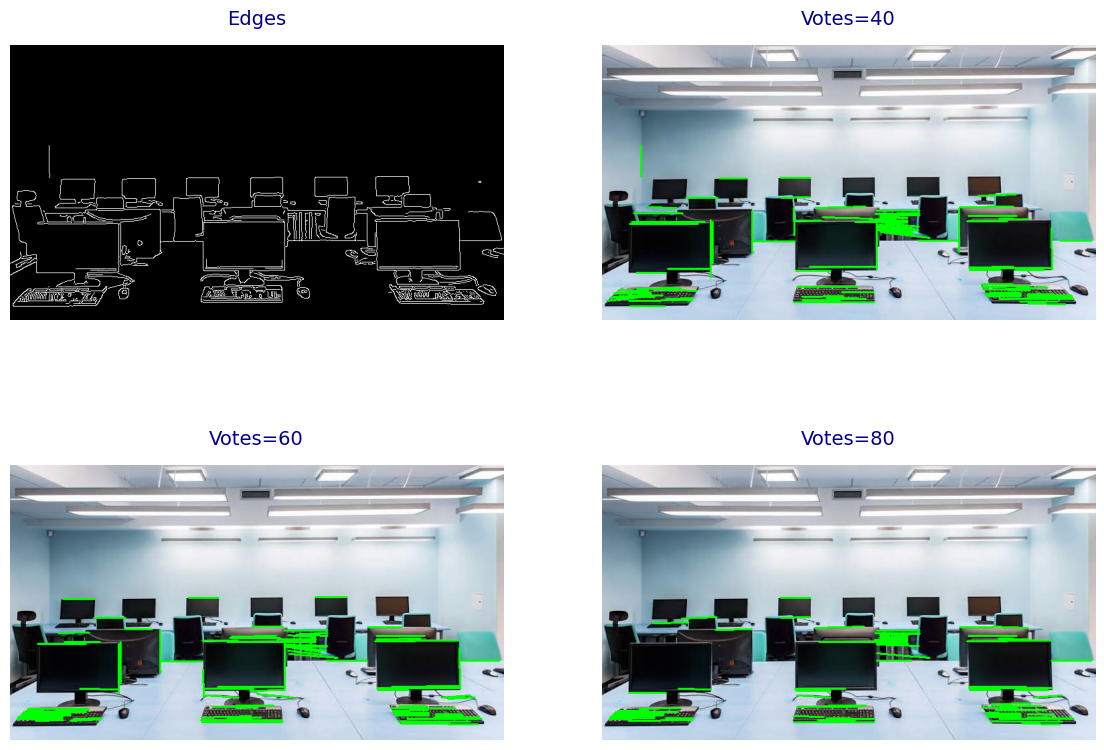

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 2 - sift

In [4]:
image_path = 'computer-lab.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
img.shape

(411, 738, 3)

In [5]:
sift = cv2.SIFT_create()
bf = cv2.BFMatcher()

def locate(ref, scene, ratio=0.75):
  k1, d1 = sift.detectAndCompute(ref, None)
  k2, d2 =  sift.detectAndCompute(scene, None)
  pairs = bf.knnMatch(d1, d2, k=2)
  good = [m for m, n in pairs if m.distance < ratio * n.distance]
  if len(good) < 4:
    return None, len(good), 0
  src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
  dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
  H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
  if H is None:
        return None, len(good), 0
  h, w = ref.shape[:2]
  corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
  return cv2.perspectiveTransform(corners, H), len(good), int(mask.sum())

In [12]:
assets = {
    'Front computer': (305, 290, 495, 480),
    'Second row monitor': (185, 225, 285, 300),
}
refs = {name: img[y1:y2, x1:x2] for name, (x1, y1, x2, y2) in assets.items()}

src_pts = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
dst_pts = np.float32([[60, 40], [w - 30, 80], [w - 70, h - 40], [20, h - 90]])
P = cv2.getPerspectiveTransform(src_pts, dst_pts)
scene = cv2.warpPerspective(img, P, (w, h), borderValue=(128, 128, 128))
scene = cv2.convertScaleAbs(scene, alpha=0.85, beta=20)

In [13]:
result = scene.copy()
for name, ref in refs.items():
    box, good, inliers = locate(ref, result)
    print(f'{name} - good matches:', good, 'inliers:', inliers)
    if box is not None:
        cv2.polylines(result, [np.int32(box)], True, (0, 255, 0), 3)
        x, y = np.int32(box[0, 0])
        cv2.putText(result, name, (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

Front computer - good matches: 18 inliers: 17
Second row monitor - good matches: 6 inliers: 6


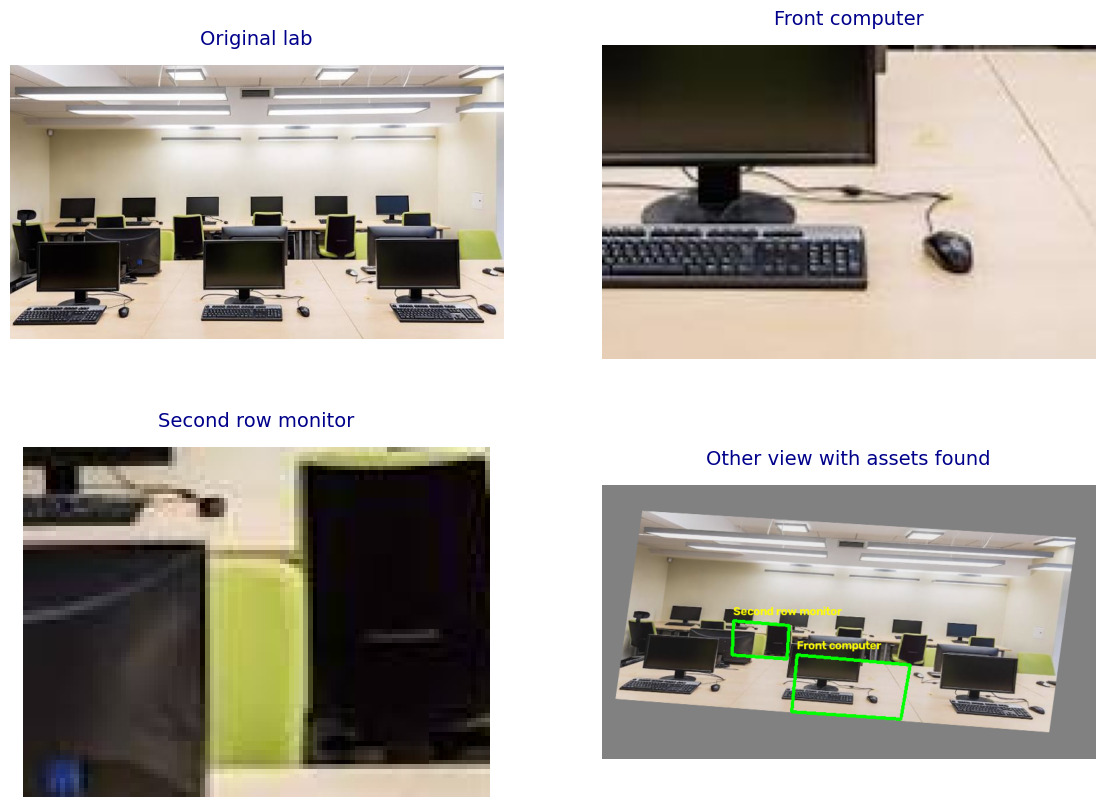

In [14]:
panels = [('Original lab', img), ('Front computer', refs['Front computer']), ('Second row monitor', refs['Second row monitor']), ('Other view with assets found', result)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()